In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from FwdNeuron import *
from DeepEligNeuron import *
from Network import *
from inputFuc import *
from utils import *
from plotting import *
from utilsMNIST import *

# MNIST-1D

Templates for the MNIST-1D dataset:


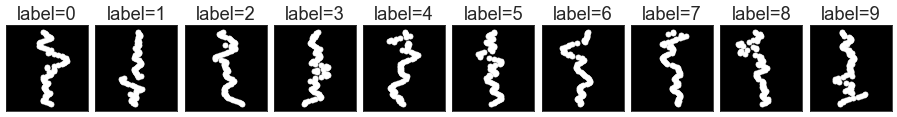

In [2]:
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals
###TODO padding###
data_config = default_data_config
general_config = default_general_config
train_config = default_train_config
model_config = default_model_config

data = make_dataset(ObjectView(data_config))

templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=ObjectView(data_config),
                   ratio=1.33, dark_mode=True, do_transform=True)

In [3]:
print(data.keys())
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'])
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'])
x.shape, y.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 72, 1]), torch.Size([4000]))

In [4]:
#### With P learning ###
dt = general_config["dt"]
n_steps = data_config["final_seq_length"]
answer_period = 48

# init both teacher and student net
batch = train_config["batch_size"]

model = buildMNISTNet(model_config, general_config)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4#train_config["learning_rate"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.4,
    patience=2
)

kernel_record_pre = extract_kernel(
    model, 
    n_steps=int(1.5*data_config["final_seq_length"]), 
    layer_idx=model_config["num_LP_layers"]-1
)

In [5]:
error_record, mismatch_record = [], []
Cum_errors = 0.5
num_epochs = 50

with torch.no_grad():
    for epoch in range(num_epochs):
        permu = np.random.permutation(4000).reshape(-1, batch)
        pbar = tqdm(
            permu,
            total=permu.shape[0],
        )
        for idx in pbar:
            total_error = train_batch(model, optimizer, x[idx], y[idx], answer_period)
            Cum_errors = 0.95*Cum_errors + 0.05*total_error
                
        test_acc, test_loss = test(model, x_test, y_test, answer_period)
        scheduler.step(test_loss)
        error_record.append(Cum_errors)   
        print("Train loss: %3f, Test acc: %2f, Epoch: %d"%(Cum_errors, test_acc, epoch+1))
                
print('finished')

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 11.02it/s]


Train loss: 0.185755, Test acc: 0.342000, Epoch: 1


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.97it/s]


Train loss: 0.177662, Test acc: 0.397000, Epoch: 2


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 11.02it/s]


...

Train loss: 0.138720, Test acc: 0.598000, Epoch: 48


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.15it/s]


Train loss: 0.142145, Test acc: 0.600000, Epoch: 49


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.89it/s]


Train loss: 0.139272, Test acc: 0.597000, Epoch: 50
finished


In [8]:
for l in model.layers[:2]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

tensor([1.2000, 3.1000, 8.1000, 1.1000, 3.0000, 8.0000]) tensor([0.5833, 0.8387, 0.9383, 0.5455, 0.8333, 0.9375])
torch.Size([1, 6, 60, 1]) tensor(0.)
tensor(1.1393, grad_fn=<MeanBackward0>) tensor(0.1725, grad_fn=<MeanBackward0>)

tensor([1.2000, 3.1000, 8.1000]) tensor([0.5833, 0.8387, 0.9383])
torch.Size([1, 3, 60, 60]) tensor(0.)
tensor(0.2200, grad_fn=<MeanBackward0>) tensor(0.1231, grad_fn=<MeanBackward0>)



In [16]:
#TEST
acc, loss = test(model, x_test, y_test, 1*answer_period)
print('Test Accuracy: ', acc, "Test Loss", loss)

Test Accuracy:  0.5360000133514404 Test Loss 0.12214948982000351


In [6]:
kernel_record_post = extract_kernel(
    model, 
    n_steps=int(1.5*data_config["final_seq_length"]), 
    layer_idx=model_config["num_LP_layers"]-1
)

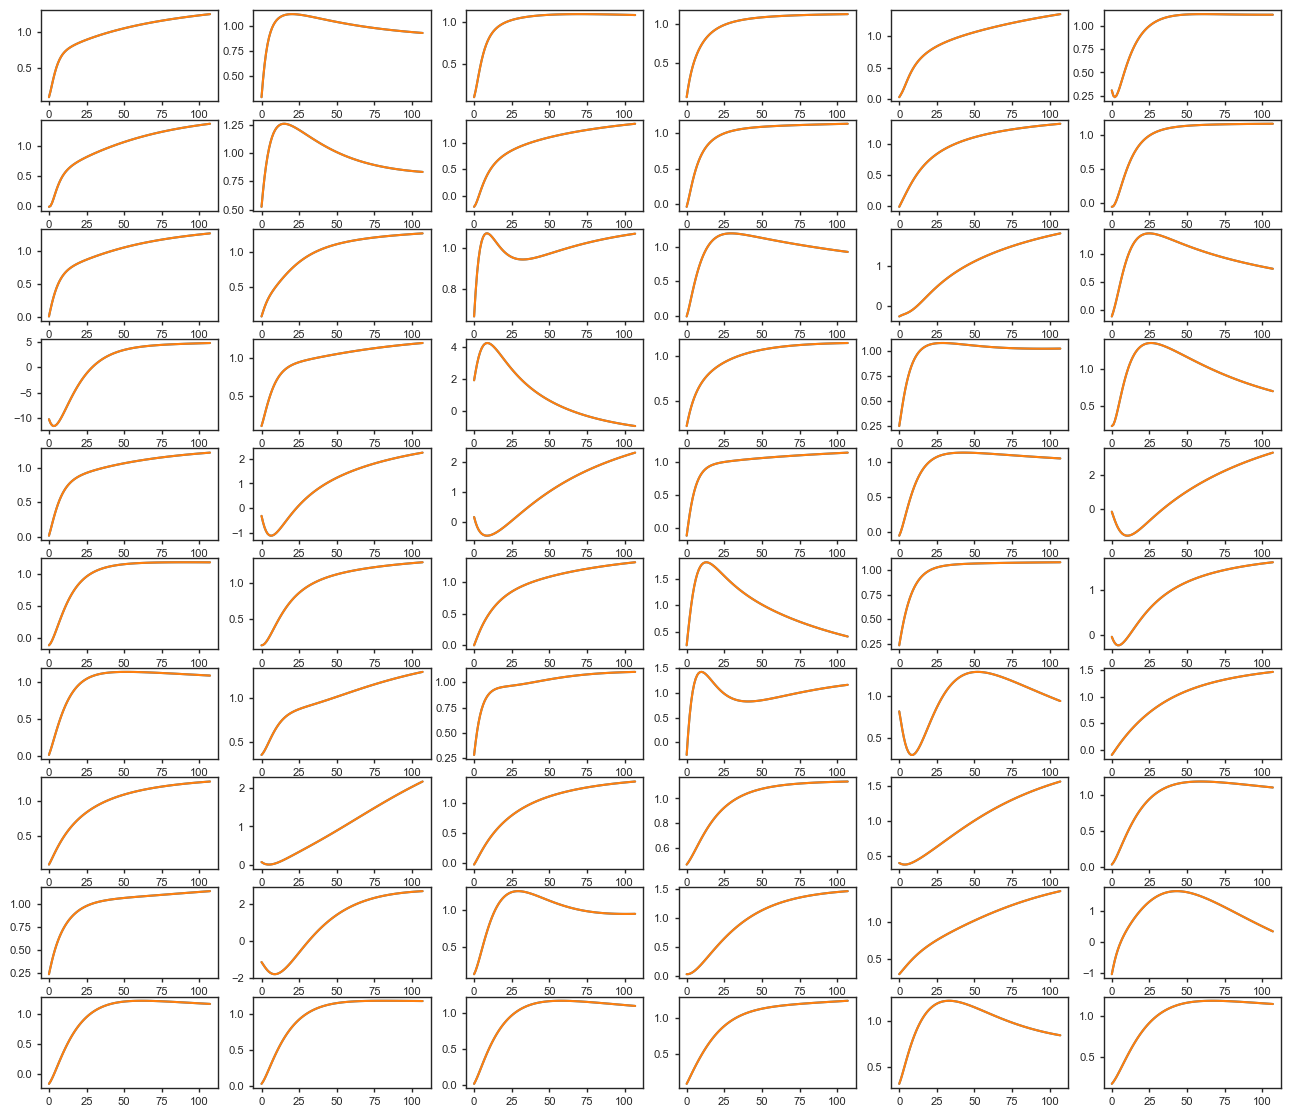

In [7]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

## Check BPTT

In [19]:
#### With P learning ###
dt = general_config["dt"]
n_steps = data_config["final_seq_length"]
answer_period = 36

# init both teacher and student net
batch = train_config["batch_size"]

model = buildMNISTNet(model_config, general_config)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4#train_config["learning_rate"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.4,
    patience=2
)
loss_fn = torch.nn.CrossEntropyLoss()

kernel_record = extract_kernel(model, n_steps=int(1.5*data_config["final_seq_length"]), layer_idx=model_config["num_LP_layers"])
kernel_record_pre = kernel_record.numpy().T

In [9]:
num_epochs = 1
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(num_epochs):
    permu = np.random.permutation(4000).reshape(-1, batch)
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        n_steps = x.shape[1]
        total_error = 0.
        one_hot_label = F.one_hot(y, num_classes=10).type(torch.FloatTensor)
        model.reset()
        prex = torch.zeros(x.shape[0], 1)
        for t in range(4):
            r_out,_ = model.step(prex)
        for t in range(n_steps):
            r_out,_ = model.step(x[:, t])
            if n_steps-t <= answer_period:
                total_error += loss_fn(r_out, one_hot_label)/answer_period
        total_error.backward()
        optimizer.step()
        optimizer.zero_grad()
            
        Cum_errors = 0.95*Cum_errors + 0.05*total_error
            
    test_acc, test_loss = test(model, x_test, y_test, answer_period)
    scheduler.step(test_loss)
    error_record.append(Cum_errors)   
    print("Train loss: %3f, Test acc: %2f, Epoch: %d"%(Cum_errors, test_acc, epoch+1))
                
print('finished')

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [08:19<00:00,  5.00s/it]


Train loss: 1.367589, Test acc: 0.546000, Epoch: 1
finished
